# 📈 Algoritmos de Ejecución VWAP
## *Estrategias de Trading Algorítmico Avanzadas*

---

### 🎯 **Introducción**

El objetivo de este ejercicio es programar una **estrategia de ejecución algorítmica** que trate de lograr un coste de ejecución cercano al benchmark de mercado **VWAP** (*Volume Weighted Average Price - Precio Promedio Ponderado por Volumen*). 

Sigue la estrategia de ejecución óptima para seguir el VWAP discutida en *Busseti & Boyd (2015)*, ver las notas del curso para más detalles. 

#### 📋 **Estructura del Ejercicio:**
1. **Diseño** de un predictor de volumen de mercado
2. **Validación** y pruebas del predictor
3. **Integración** en una estrategia de ejecución
4. **Análisis** de rendimiento usando backtesting

> **🎯 Entregable:** Notebook de Jupyter (Python) con todas las partes obligatorias del ejercicio y resultados

---

## 📊 **1. Lectura y Preparación de Datos**

### 🔄 **Importación de Librerías y Configuración**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_df = pd.read_csv("volume_price_2014_18.csv")

In [3]:
data_df

,date,time,volume,price
0,2014-01-02,09:00:00,121,130.9000
1,2014-01-02,09:01:00,8800,130.9871
2,2014-01-02,09:02:00,9826,131.0056
3,2014-01-02,09:03:00,2470,131.1932
4,2014-01-02,09:04:00,3515,131.3129
...,...,...,...,...
534475,2018-04-09,17:25:00,2579,187.2342
534476,2018-04-09,17:26:00,4825,187.1532
534477,2018-04-09,17:27:00,2669,187.1875
534478,2018-04-09,17:28:00,2296,187.2329


Analizando los primeros 7 días:
  1. 2014-01-02 (Thursday): 1,280,093 unidades
  2. 2014-01-03 (Friday): 626,233 unidades
  3. 2014-01-06 (Monday): 704,945 unidades
  4. 2014-01-07 (Tuesday): 924,455 unidades
  5. 2014-01-08 (Wednesday): 854,336 unidades
  6. 2014-01-09 (Thursday): 847,439 unidades
  7. 2014-01-10 (Friday): 857,697 unidades


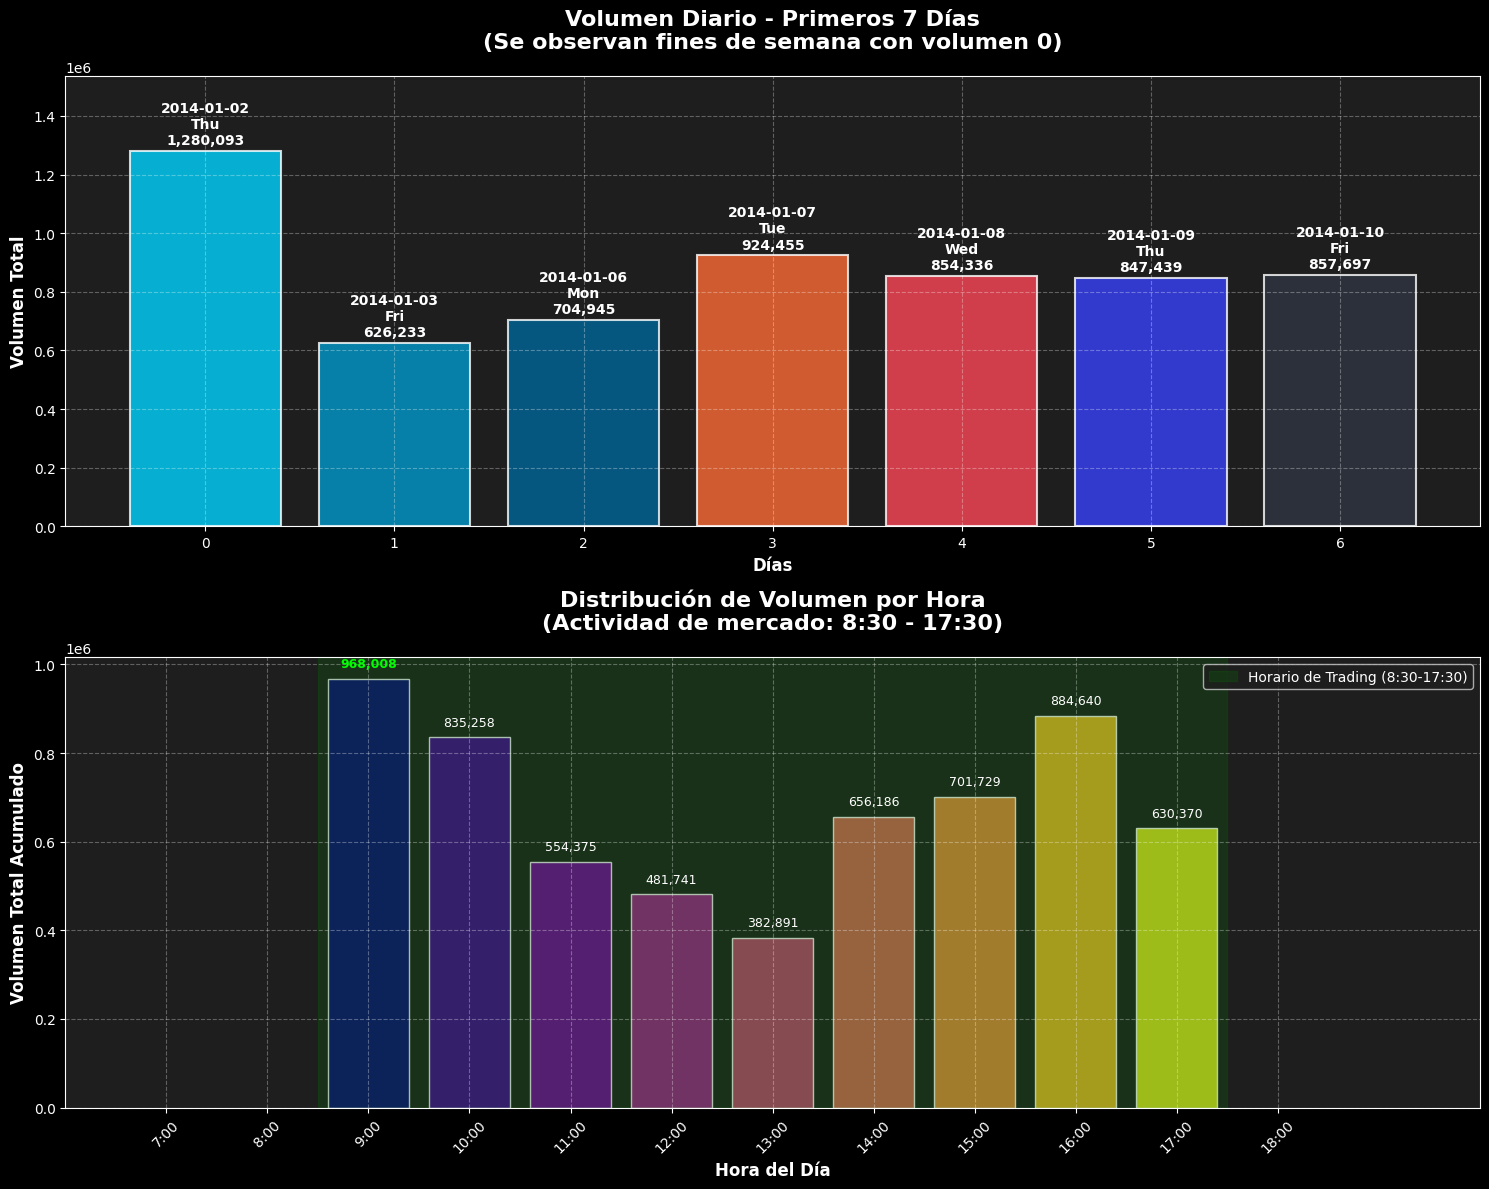


RESUMEN ESTADÍSTICO - PRIMEROS 7 DÍAS
Volumen total: 6,095,198 unidades
Días de trading: 7 días
Días sin actividad (fines de semana): 0 días
Hora pico: 9:00 (968,008 unidades)
Volumen promedio por día de trading: 870,743 unidades
Horario activo: 9:00 - 17:00
Horario oficial de trading: 8:30 - 17:30


In [4]:
# Análisis de los primeros 7 días - Patrones de volumen
# =====================================================

# Configurar estilo profesional y oscuro
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = '#1e1e1e'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'

# Obtener los primeros 7 días únicos
unique_dates = data_df['date'].unique()[:7]
first_7_days = data_df[data_df['date'].isin(unique_dates)].copy()  # Use .copy() to avoid SettingWithCopyWarning

print(f"Analizando los primeros 7 días:")
for i, date in enumerate(unique_dates):
    day_volume = first_7_days[first_7_days['date'] == date]['volume'].sum()
    day_name = pd.to_datetime(date).strftime('%A')
    print(f"  {i+1}. {date} ({day_name}): {day_volume:,.0f} unidades")

# =============================================================================
# 1. HISTOGRAMA POR DÍA - Distribución de volumen diario
# =============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
fig.patch.set_facecolor('black')

# Calcular volumen total por día
daily_volumes = first_7_days.groupby('date')['volume'].sum()

# Colores profesionales con gradiente
colors = ['#00d4ff', '#0099cc', '#006699', '#ff6b35', '#ff4757', '#3742fa', '#2f3542']

# Plot 1: Histograma de volumen por día
bars = ax1.bar(range(len(daily_volumes)), daily_volumes.values, 
               color=colors[:len(daily_volumes)], alpha=0.8, edgecolor='white', linewidth=1.5)

# Personalización del primer plot (sin emojis para evitar warnings)
ax1.set_title('Volumen Diario - Primeros 7 Días\n(Se observan fines de semana con volumen 0)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Días', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volumen Total', fontsize=12, fontweight='bold')

# Etiquetas en las barras
for i, (bar, volume) in enumerate(zip(bars, daily_volumes.values)):
    height = bar.get_height()
    day_name = pd.to_datetime(daily_volumes.index[i]).strftime('%a')
    if volume == 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(daily_volumes.values)*0.01,
                f'{daily_volumes.index[i]}\n{day_name}\nFIN DE SEMANA', 
                ha='center', va='bottom', fontweight='bold', color='#ff4757', fontsize=10)
    else:
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(daily_volumes.values)*0.01,
                f'{daily_volumes.index[i]}\n{day_name}\n{volume:,.0f}', 
                ha='center', va='bottom', fontweight='bold', color='white', fontsize=10)

ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(daily_volumes.values) * 1.2)

# =============================================================================
# 2. DISTRIBUCIÓN HORARIA - Volumen por franja horaria
# =============================================================================

# Agrupar por hora para ver el patrón horario (sin warning)
first_7_days.loc[:, 'hour'] = pd.to_datetime(first_7_days['time'], format='%H:%M:%S').dt.hour
hourly_volumes = first_7_days.groupby('hour')['volume'].sum()

# Crear gradiente de colores para las horas
hour_colors = plt.cm.plasma(np.linspace(0, 1, len(hourly_volumes)))

# Plot 2: Distribución horaria
bars2 = ax2.bar(hourly_volumes.index, hourly_volumes.values, 
                color=hour_colors, alpha=0.8, edgecolor='white', linewidth=1)

# Personalización del segundo plot (horario actualizado a 8:30-17:30)
ax2.set_title('Distribución de Volumen por Hora\n(Actividad de mercado: 8:30 - 17:30)', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Hora del Día', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volumen Total Acumulado', fontsize=12, fontweight='bold')

# Marcar horarios de trading actualizados (8:30 - 17:30)
trading_start = 8.5  # 8:30
trading_end = 17.5   # 17:30
ax2.axvspan(trading_start, trading_end, alpha=0.2, color='green', label='Horario de Trading (8:30-17:30)')

# Etiquetas en las barras más significativas
max_volume_hour = hourly_volumes.idxmax()
for hour, volume in hourly_volumes.items():
    if volume > hourly_volumes.max() * 0.1:  # Solo mostrar horas con volumen significativo
        color = '#00ff00' if hour == max_volume_hour else 'white'
        weight = 'bold' if hour == max_volume_hour else 'normal'
        ax2.text(hour, volume + hourly_volumes.max()*0.02, 
                f'{volume:,.0f}', ha='center', va='bottom', 
                color=color, fontweight=weight, fontsize=9)

ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(6, 20)  # Mostrar desde las 6 AM hasta las 8 PM
ax2.legend(loc='upper right')

# Configurar ticks del eje x para mostrar horas
ax2.set_xticks(range(7, 19))
ax2.set_xticklabels([f'{h}:00' for h in range(7, 19)], rotation=45)

plt.tight_layout()
plt.show()

# =============================================================================
# 3. RESUMEN ESTADÍSTICO
# =============================================================================

print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO - PRIMEROS 7 DÍAS")
print("="*60)

total_volume = first_7_days['volume'].sum()
trading_days = (daily_volumes > 0).sum()
weekend_days = (daily_volumes == 0).sum()

print(f"Volumen total: {total_volume:,.0f} unidades")
print(f"Días de trading: {trading_days} días")
print(f"Días sin actividad (fines de semana): {weekend_days} días")
print(f"Hora pico: {max_volume_hour}:00 ({hourly_volumes[max_volume_hour]:,.0f} unidades)")
print(f"Volumen promedio por día de trading: {daily_volumes[daily_volumes > 0].mean():,.0f} unidades")

# Mostrar el rango de horas activas
active_hours = hourly_volumes[hourly_volumes > 0]
if len(active_hours) > 0:
    print(f"Horario activo: {active_hours.index.min()}:00 - {active_hours.index.max()}:00")
    print(f"Horario oficial de trading: 8:30 - 17:30")
    
print("="*60)

### 🔧 **2. Resample the data to intervals of five minutes**

#### 📋 **Instrucciones de Remuestreo:**

Remuestrea los datos a **intervalos de cinco minutos** para facilitar la tarea de predicción de volumen:

> **📌 Especificaciones:**
> - **Volumen:** Suma de volúmenes para cada intervalo de un minuto
> - **Precio:** Precio promedio ponderado por volumen de los intervalos de un minuto
> - **Resultado:** Conjunto de datos con una fila por día y una columna por intervalo de 5 minutos (bin)

> ⚠️ **Verificación de Cordura:** El volumen total por día después del remuestreo no puede cambiar con respecto a los intervalos originales de un minuto.

**Sigue las instrucciones dadas para realizar esta tarea:**

In [5]:
data_df['datetime'] = pd.to_datetime(data_df['date'] + ' ' + data_df['time'], format='%Y-%m-%d %H:%M:%S')
data_df.set_index("datetime", inplace = True)

In [6]:
def vwap(price, volume):
    total_volume = np.sum(volume)
    if total_volume == 0:
        return np.nan  # Return NaN when volume is zero to avoid division by zero
    return round(np.sum(price * volume) / total_volume, 2)  # Round to 2 decimal places

data_resample_vwap = data_df.resample('5min').apply(lambda x: vwap(x['price'], x['volume']))
data_resample_df = data_df.resample('5min').agg({"volume": "sum"})  # Use string instead of function
data_resample_df["vwap"] = data_resample_vwap

In [7]:
data_resample_df["time"] = data_resample_df.index.time
data_resample_df["date"] = data_resample_df.index.date
data_resample_df["day_of_week"] = data_resample_df.index.day_of_week

In [8]:
data_resample_df

,volume,vwap,time,date,day_of_week
datetime,,,,,
2014-01-02 09:00:00,24732,131.06,09:00:00,2014-01-02,3
2014-01-02 09:05:00,22744,131.24,09:05:00,2014-01-02,3
2014-01-02 09:10:00,23342,131.22,09:10:00,2014-01-02,3
2014-01-02 09:15:00,24077,131.22,09:15:00,2014-01-02,3
2014-01-02 09:20:00,24417,131.05,09:20:00,2014-01-02,3
...,...,...,...,...,...
2018-04-09 17:05:00,10226,187.04,17:05:00,2018-04-09,0
2018-04-09 17:10:00,4150,187.05,17:10:00,2018-04-09,0
2018-04-09 17:15:00,11959,187.25,17:15:00,2018-04-09,0


### 🧹 **Limpieza de Datos**

**Filtra tu conjunto de datos para eliminar:**
- 📅 Días "5" y "6" (fines de semana)
- ⏰ Horas de trading fuera de **9:00:00 a 17:30:00**

In [9]:
# focus on business days and trading hours
data_resample_df = data_resample_df[data_resample_df["day_of_week"] != 5]
data_resample_df = data_resample_df[data_resample_df["day_of_week"] != 6]
data_resample_df = data_resample_df[data_resample_df["time"] < pd.to_datetime("17:30:00").time()]
data_resample_df = data_resample_df[data_resample_df["time"] >= pd.to_datetime("09:00:00").time()]

In [10]:
# show me rows where volume is 0
data_resample_df[data_resample_df["volume"] == 0]

# Organize data_resample_df[data_resample_df["volume"] == 0] by date and time
data_resample_df[data_resample_df["volume"] == 0].sort_values(by=["date", "time"])

# count how many intervals with volume 0 by date
data_resample_df[data_resample_df["volume"] == 0].groupby("date").count()

,volume,vwap,time,day_of_week
date,,,,
2014-01-17,1,0,1,1
2014-02-18,1,0,1,1
2014-03-21,1,0,1,1
2014-04-17,1,0,1,1
2014-04-18,102,0,102,102
...,...,...,...,...
2017-12-29,102,0,102,102
2018-01-01,102,0,102,102
2018-03-16,102,0,102,102


### 📊 **3. División Train/Test**

**Divide el conjunto de datos en dos partes:**
- 🏋️ **Entrenamiento:** Primeros tres años
- 🧪 **Prueba:** Último año

> ⚠️ **¡IMPORTANTE!** No uses el conjunto de prueba en ninguna etapa de entrenamiento. Se usará exclusivamente para evaluar el rendimiento de tu modelo y algoritmo de ejecución.

In [11]:
# Specify the split date
split_date = pd.to_datetime('2017-01-01').date()

# Create a boolean mask indicating which rows should be in the train set
train_mask = data_resample_df["date"] < split_date

# Create the train and test sets using boolean indexing
train_set = data_resample_df[train_mask]
test_set = data_resample_df[~train_mask]

## 📈 **4. Estadísticas Generales del Training Set**

### **Análisis de Volumen Diario**

Para cada día en el conjunto de entrenamiento, **calcula el volumen total de mercado del día** y grafica el histograma:

In [12]:
daily_train_set = train_set.resample('D').agg({"volume": "sum"})

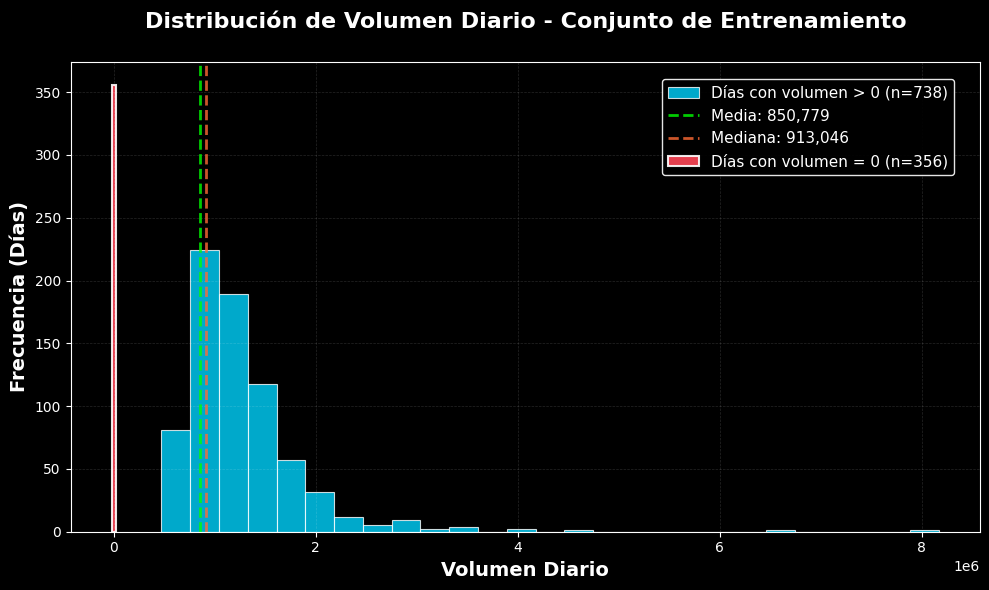

ANÁLISIS DETALLADO DEL VOLUMEN DIARIO - CONJUNTO DE ENTRENAMIENTO
📊 ESTADÍSTICAS BÁSICAS:
   • Total de días analizados: 1,094
   • Días con volumen > 0: 738 (67.5%)
   • Días con volumen = 0: 356 (32.5%)

📈 MEDIDAS DE TENDENCIA CENTRAL:
   • Media: 850,779 unidades
   • Mediana: 913,046 unidades
   • Diferencia (Media - Mediana): -62,268 unidades

📏 MEDIDAS DE DISPERSIÓN:
   • Desviación estándar: 776,620 unidades
   • Coeficiente de variación: 91.3%
   • Rango: 470,140 - 8,169,052


In [13]:
# Análisis Profesional del Volumen Diario de Entrenamiento
# =======================================================

# Extraer datos de volumen diario
volume_data = daily_train_set['volume']

# Calcular estadísticas básicas necesarias para el gráfico
mean_vol = volume_data.mean()
median_vol = volume_data.median()
std_vol = volume_data.std()

# Configurar estilo oscuro profesional
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('black')

# =============================================================================
# Histograma Principal con Granularidad Mejorada
# =============================================================================

# Separar días con volumen 0 del resto para tratamiento especial
zero_volume_days = volume_data[volume_data == 0]
non_zero_volume_days = volume_data[volume_data > 0]

# Calcular estadísticas básicas necesarias para el gráfico
mean_vol = volume_data.mean()
median_vol = volume_data.median()

# Calcular bins adaptativos para mejor granularidad
n_bins = min(50, max(20, int(np.sqrt(len(non_zero_volume_days)))))

# Crear histograma principal con colores diferenciados
counts, bins, patches = ax.hist(non_zero_volume_days, bins=n_bins, 
                               alpha=0.8, color='#00d4ff', 
                               edgecolor='white', linewidth=0.8,
                               label=f'Días con volumen > 0 (n={len(non_zero_volume_days)})')

# Agregar barra especial para días con volumen 0 si existen
if len(zero_volume_days) > 0:
    ax.bar(0, len(zero_volume_days), width=bins[1]*0.05, 
           color='#ff4757', alpha=0.9, edgecolor='white', linewidth=1.5,
           label=f'Días con volumen = 0 (n={len(zero_volume_days)})')

# Personalización del histograma principal
ax.set_title('Distribución de Volumen Diario - Conjunto de Entrenamiento', 
             fontsize=16, fontweight='bold', pad=25, color='white')
ax.set_xlabel('Volumen Diario', fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Frecuencia (Días)', fontsize=14, fontweight='bold', color='white')

# Pinta la mediana y la media
ax.axvline(mean_vol, color='#00ff00', linestyle='--', linewidth=2, alpha=0.8, label=f'Media: {mean_vol:,.0f}')
ax.axvline(median_vol, color='#ff6b35', linestyle='--', linewidth=2, alpha=0.8, label=f'Mediana: {median_vol:,.0f}')

# Actualizar la leyenda para incluir las nuevas líneas
ax.legend(loc='upper right', framealpha=0.9, 
          bbox_to_anchor=(0.98, 0.98), fontsize=11,
          facecolor='black', edgecolor='white')

ax.grid(True, alpha=0.15, color='white', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# =============================================================================
# RESUMEN ESTADÍSTICO DETALLADO
# =============================================================================

print("=" * 70)
print("ANÁLISIS DETALLADO DEL VOLUMEN DIARIO - CONJUNTO DE ENTRENAMIENTO")
print("=" * 70)

print(f"📊 ESTADÍSTICAS BÁSICAS:")
print(f"   • Total de días analizados: {len(volume_data):,}")
print(f"   • Días con volumen > 0: {len(non_zero_volume_days):,} ({len(non_zero_volume_days)/len(volume_data)*100:.1f}%)")
print(f"   • Días con volumen = 0: {len(zero_volume_days):,} ({len(zero_volume_days)/len(volume_data)*100:.1f}%)")

print(f"\n📈 MEDIDAS DE TENDENCIA CENTRAL:")
print(f"   • Media: {mean_vol:,.0f} unidades")
print(f"   • Mediana: {median_vol:,.0f} unidades")
print(f"   • Diferencia (Media - Mediana): {mean_vol - median_vol:,.0f} unidades")

print(f"\n📏 MEDIDAS DE DISPERSIÓN:")
print(f"   • Desviación estándar: {std_vol:,.0f} unidades")
print(f"   • Coeficiente de variación: {std_vol/mean_vol*100:.1f}%")
print(f"   • Rango: {non_zero_volume_days.min():,.0f} - {non_zero_volume_days.max():,.0f}")

print("=" * 70)

Value count de días con volumen = 0:
volume
0    356
Name: count, dtype: int64
Total días con volumen = 0: 356


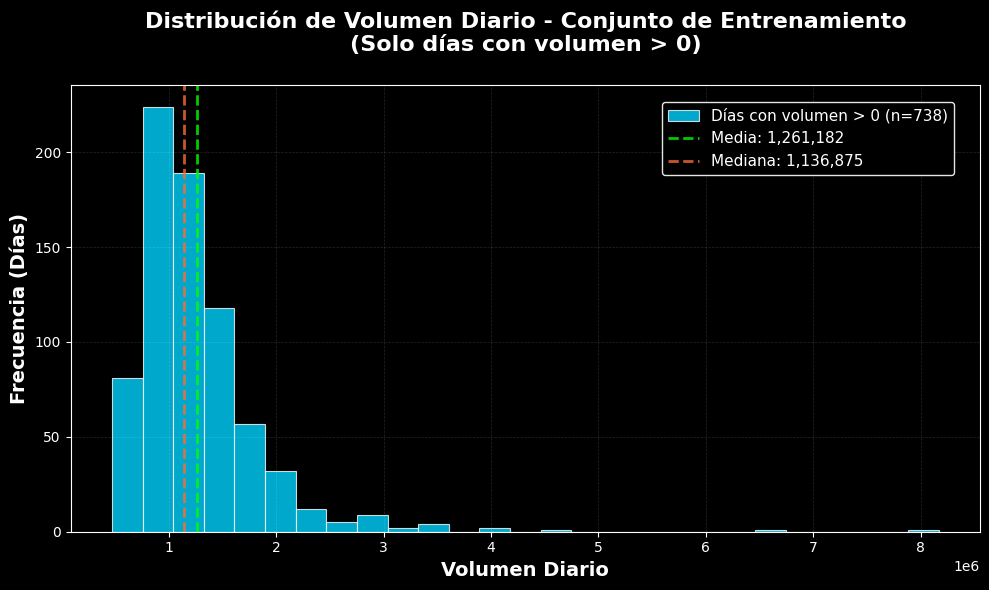

ANÁLISIS DETALLADO DEL VOLUMEN DIARIO - CONJUNTO DE ENTRENAMIENTO
(Solo días con volumen > 0)
📊 ESTADÍSTICAS BÁSICAS:
   • Total de días analizados: 738

📈 MEDIDAS DE TENDENCIA CENTRAL:
   • Media: 1,261,182 unidades
   • Mediana: 1,136,875 unidades
   • Diferencia (Media - Mediana): 124,307 unidades

📏 MEDIDAS DE DISPERSIÓN:
   • Desviación estándar: 613,337 unidades
   • Coeficiente de variación: 48.6%
   • Rango: 470,140 - 8,169,052


In [14]:
# Análisis Profesional del Volumen Diario de Entrenamiento
# =======================================================

# Extraer datos de volumen diario
volume_data = daily_train_set['volume']

# Value count de días con valores 0
print("Value count de días con volumen = 0:")
print(volume_data[volume_data == 0].value_counts())
print(f"Total días con volumen = 0: {len(volume_data[volume_data == 0])}")

# Quitar esos días con valores 0
volume_data = volume_data[volume_data > 0]

# Calcular estadísticas básicas necesarias para el gráfico (solo días con volumen > 0)
mean_vol = volume_data.mean()
median_vol = volume_data.median()
std_vol = volume_data.std()

# Configurar estilo oscuro profesional
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('black')

# =============================================================================
# Histograma Principal con Granularidad Mejorada (solo días con volumen > 0)
# =============================================================================

# Calcular bins adaptativos para mejor granularidad
n_bins = min(50, max(20, int(np.sqrt(len(volume_data)))))

# Crear histograma principal
counts, bins, patches = ax.hist(volume_data, bins=n_bins,
                               alpha=0.8, color='#00d4ff',
                               edgecolor='white', linewidth=0.8,
                               label=f'Días con volumen > 0 (n={len(volume_data)})')

# Personalización del histograma principal
ax.set_title('Distribución de Volumen Diario - Conjunto de Entrenamiento\n(Solo días con volumen > 0)',
             fontsize=16, fontweight='bold', pad=25, color='white')
ax.set_xlabel('Volumen Diario', fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Frecuencia (Días)', fontsize=14, fontweight='bold', color='white')

# Pinta la mediana y la media
ax.axvline(mean_vol, color='#00ff00', linestyle='--', linewidth=2, alpha=0.8, label=f'Media: {mean_vol:,.0f}')
ax.axvline(median_vol, color='#ff6b35', linestyle='--', linewidth=2, alpha=0.8, label=f'Mediana: {median_vol:,.0f}')

# Actualizar la leyenda
ax.legend(loc='upper right', framealpha=0.9,
          bbox_to_anchor=(0.98, 0.98), fontsize=11,
          facecolor='black', edgecolor='white')

ax.grid(True, alpha=0.15, color='white', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# =============================================================================
# RESUMEN ESTADÍSTICO DETALLADO (solo días con volumen > 0)
# =============================================================================

print("=" * 70)
print("ANÁLISIS DETALLADO DEL VOLUMEN DIARIO - CONJUNTO DE ENTRENAMIENTO")
print("(Solo días con volumen > 0)")
print("=" * 70)

print(f"📊 ESTADÍSTICAS BÁSICAS:")
print(f"   • Total de días analizados: {len(volume_data):,}")

print(f"\n📈 MEDIDAS DE TENDENCIA CENTRAL:")
print(f"   • Media: {mean_vol:,.0f} unidades")
print(f"   • Mediana: {median_vol:,.0f} unidades")
print(f"   • Diferencia (Media - Mediana): {mean_vol - median_vol:,.0f} unidades")

print(f"\n📏 MEDIDAS DE DISPERSIÓN:")
print(f"   • Desviación estándar: {std_vol:,.0f} unidades")
print(f"   • Coeficiente de variación: {std_vol/mean_vol*100:.1f}%")
print(f"   • Rango: {volume_data.min():,.0f} - {volume_data.max():,.0f}")

print("=" * 70)

### 🧮 **Cálculo del ADV (Average Daily Volume)**

Calcula el volumen diario promedio (**ADV**) como **media** y también como **mediana** sobre los volúmenes diarios:

#### 🤔 **Preguntas para Reflexionar:**
- ¿Cuánto difieren?
- ¿Cuáles son las ventajas y desventajas de usar mediana vs media para obtener una estimación "promedio"?

> 💡 **PISTA:** Tiene que ver con la influencia de los valores atípicos

In [15]:

median_volume = volume_data.median()
mean_volume = volume_data.mean()
print("median: ", median_volume)
print("mean: ", mean_volume)

median:  1136875.0
mean:  1261181.7411924119


### 📅 **Análisis por Día de la Semana**

Separa el conjunto de entrenamiento en **días de la semana** (lunes, martes... viernes) y rehaz el análisis para cada día de la semana:

#### 🔍 **Preguntas de Análisis:**
- ¿Ves alguna diferencia significativa entre estos resultados y los resultados globales?
- ¿Ves algún patrón a lo largo de los días de la semana?

In [16]:
day_of_week_train = train_set[["date", "day_of_week", "volume"]].groupby(["date", "day_of_week"]).sum()

In [17]:
day_of_week_train.groupby(["day_of_week"]).median()

,volume
day_of_week,
0,995237.0
1,1108874.0
2,1083281.0
3,1154584.0
4,1183888.0


### 🎯 **[Opcional] Consideración de Días Especiales**

#### 🤔 **Preguntas Avanzadas:**
- ¿Puedes pensar en otros tipos de **días especiales** donde se debería construir una curva de volumen específica?
- ¿Qué tipo de **perfiles de volumen** tienen estos días?

> 💡 *Ejemplos: días de vencimiento de opciones, anuncios de resultados, días festivos, etc.*

Top 5 días con más volumen:
1. 2014-09-26 00:00:00: 8,169,052 unidades
2. 2016-06-24 00:00:00: 6,628,156 unidades
3. 2015-08-24 00:00:00: 4,521,604 unidades
4. 2014-11-07 00:00:00: 4,149,860 unidades
5. 2014-10-16 00:00:00: 3,893,388 unidades


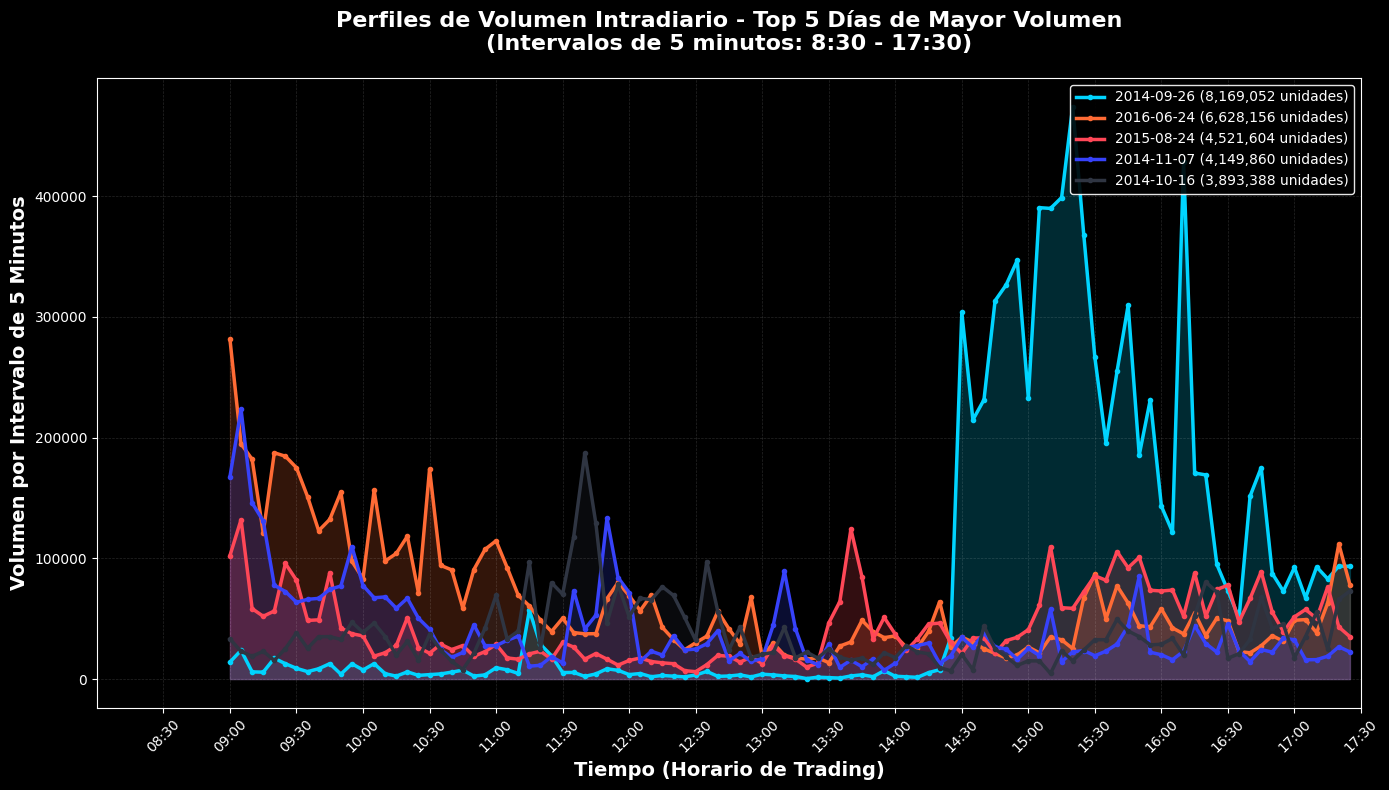

In [18]:
# Identificar días con más volumen (filtrando días con volumen > 0)
volume_filtered = daily_train_set['volume'][daily_train_set['volume'] > 0]

# Obtener top 5 días con más volumen
top_5_days = volume_filtered.nlargest(5)

print("Top 5 días con más volumen:")
for i, (date, volume) in enumerate(top_5_days.items(), 1):
    print(f"{i}. {date}: {volume:,.0f} unidades")

# Construir curvas específicas para estos días
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
fig.patch.set_facecolor('black')

colors = ['#00d4ff', '#ff6b35', '#ff4757', '#3742fa', '#2f3542']

# Utilizar train_set para obtener los datos de los intervalos de 5 minutos de esos días
for i, (date, total_volume) in enumerate(top_5_days.items()):
    # Filtrar datos del día específico del train_set
    specific_day_data = train_set[train_set['date'] == date.date()].copy()
    
    # Asegurar que tenemos datos para este día
    if len(specific_day_data) > 0:
        specific_day_data = specific_day_data.sort_values('time')
        
        # Crear etiquetas de tiempo para el eje X (intervalos de 5 minutos desde 8:30 a 17:30)
        time_labels = []
        x_positions = []
        
        for j, row in specific_day_data.iterrows():
            time_obj = row['time']
            # Convertir a minutos desde 8:30 para el eje X
            minutes_from_start = (time_obj.hour - 8) * 60 + (time_obj.minute - 30)
            x_positions.append(minutes_from_start)
            time_labels.append(f"{time_obj.hour:02d}:{time_obj.minute:02d}")
        
        # Plotear la curva de volumen
        ax.plot(x_positions, specific_day_data['volume'],
                label=f'{date.strftime("%Y-%m-%d")} ({total_volume:,.0f} unidades)', 
                color=colors[i], linewidth=2.5, marker='o', markersize=3)
        
        # Rellenar área bajo la curva
        ax.fill_between(x_positions, specific_day_data['volume'],
                        color=colors[i], alpha=0.2)

# Personalización del gráfico
ax.set_title('Perfiles de Volumen Intradiario - Top 5 Días de Mayor Volumen\n(Intervalos de 5 minutos: 8:30 - 17:30)', 
             fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Tiempo (Horario de Trading)', fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Volumen por Intervalo de 5 Minutos', fontsize=14, fontweight='bold', color='white')
ax.legend(loc='upper right', framealpha=0.9, fontsize=10, facecolor='black', edgecolor='white')
ax.grid(True, alpha=0.15, color='white', linestyle='--', linewidth=0.5)

# Configurar ticks del eje x para mostrar horarios cada 30 minutos desde 8:30 a 17:30
time_ticks = []
time_tick_labels = []
for hour in range(8, 18):
    for minute in [30] if hour == 8 else [0, 30]:
        if hour == 17 and minute == 30:
            break  # Terminar en 17:30
        minutes_from_start = (hour - 8) * 60 + (minute - 30)
        time_ticks.append(minutes_from_start)
        time_tick_labels.append(f"{hour:02d}:{minute:02d}")

# Añadir 17:30 como último tick
time_ticks.append((17 - 8) * 60 + (30 - 30))
time_tick_labels.append("17:30")

ax.set_xticks(time_ticks)
ax.set_xticklabels(time_tick_labels, rotation=45)

# Limitar el eje X al horario de trading
ax.set_xlim(-30, 540)  # Desde un poco antes de 8:30 hasta un poco después de 17:30

plt.tight_layout()
plt.show()

---

## 🎯 **5. Predicción de Volumen**

### 📊 **Visión General**

En este ejercicio, vamos a construir **dos predictores de volumen diferentes**:

#### 1️⃣ **Predictor Estático** 🔒
- Solo toma información de días anteriores
- Permanece "estático" una vez que comienza la sesión de trading

#### 2️⃣ **Predictor Dinámico** 🔄  
- Usa información de días anteriores
- Adapta la predicción a la información recibida durante la sesión de trading

---

### 🔒 **5.1 Predicción de Volumen Estática**

#### 📋 **Metodología:**

Vamos a construir un **predictor de volumen estático simple** usando la **mediana de volúmenes** de los datos históricos para cada día:

> **🎯 Concepto Clave:** Para predecir el volumen en el bin ej. `9:05:00 - 9:10:00` usamos la mediana de volúmenes de los datos históricos para este bin temporal.

#### 📊 **Volumen Relativo:**
El algoritmo de ejecución que usa curvas estáticas no necesita conocer el volumen total por bin a predecir, solo la **cantidad relativa** de volumen con respecto al volumen total negociado en el día.

> 📌 **Objetivo:** Construir un predictor de volumen relativo (si sumamos las predicciones para todos los bins en un día da **1**)

**Primero, calcula la mediana de volúmenes para cada intervalo de cinco minutos a través de los días del conjunto de entrenamiento.** Tienes que obtener una única curva de volumen mediana con tantos puntos como intervalos de cinco minutos en un día. Puedes usar `.groupby` y `.median` de pandas para hacer esta tarea.

In [19]:
static_volume_df = train_set[["time", "volume"]].groupby(["time"]).median()
static_volume_df

,volume
time,
09:00:00,15135.5
09:05:00,17907.5
09:10:00,14948.0
09:15:00,14661.5
09:20:00,13793.5
...,...
17:05:00,12301.0
17:10:00,12722.0
17:15:00,15770.5


#### 📊 **Normalización a Volumen Relativo:**

Ahora crea la **distribución de volumen relativo** dividiendo cada valor por la suma total:

> ✅ **Verificación:** La suma de esta distribución de volumen relativo debe ser **1**.

In [20]:
static_volume_df['pct_volume'] = static_volume_df['volume'].apply(lambda x: x / static_volume_df["volume"].sum())

<Axes: xlabel='time'>

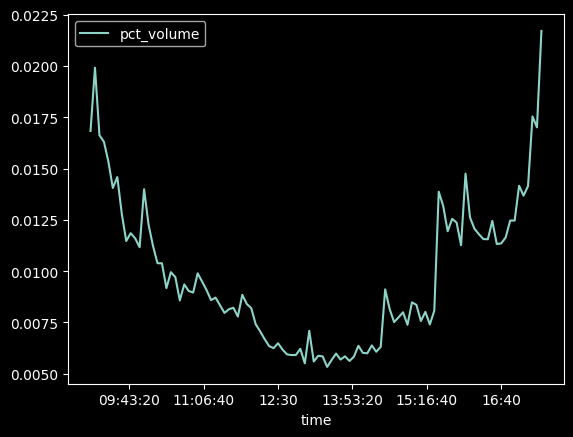

In [21]:
static_volume_df.plot(y = "pct_volume")

In [22]:
static_test_set =  test_set.reset_index()[["date", "time", "volume"]].pivot_table(index = "time", columns = "date", values = "volume", aggfunc = "first")
for col in static_test_set.columns:
  # normalize the values in the column by dividing each value by the sum of all the values in the column
  static_test_set[col] = static_test_set[col]/static_test_set[col].sum()
static_test_set = static_test_set.dropna(axis = 1)

In [23]:
dict_pred = {}
for col in static_test_set.columns:
    dict_pred[col] = static_volume_df["pct_volume"]
predictions = pd.DataFrame(dict_pred)

#### 📅 **Perfiles por Día de la Semana:**

Calcula un conjunto de **perfiles semanales** basados en patrones de día de la semana:

In [24]:
train_set[["time", "volume", "day_of_week"]].groupby(["day_of_week", "time"]).median().reset_index()

,day_of_week,time,volume
0,0,09:00:00,15811.0
1,0,09:05:00,17876.0
2,0,09:10:00,14844.5
3,0,09:15:00,13930.0
4,0,09:20:00,14064.5
...,...,...,...
505,4,17:05:00,12224.0
506,4,17:10:00,14351.0
507,4,17:15:00,15948.0
508,4,17:20:00,15903.0


array([[<Axes: xlabel='time'>, <Axes: xlabel='time'>],
       [<Axes: xlabel='time'>, <Axes: xlabel='time'>],
       [<Axes: xlabel='time'>, <Axes: xlabel='time'>]], dtype=object)

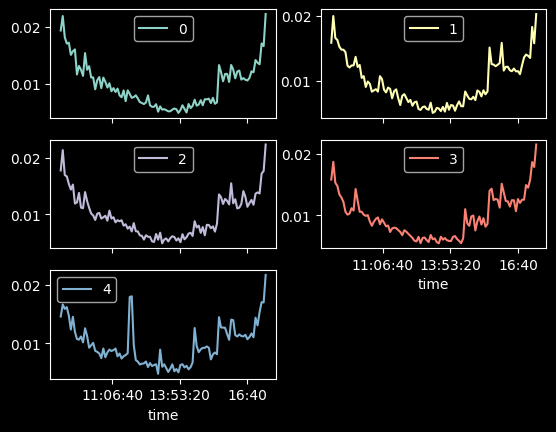

In [25]:
static_volume_day_of_week_df = train_set[["time", "volume", "day_of_week"]].groupby(["day_of_week", "time"]).median().pivot_table(index="time", columns = "day_of_week", values='volume', aggfunc='first')
for col in static_volume_day_of_week_df.columns:
  # normalize the values in the column by dividing each value by the sum of all the values in the column
  static_volume_day_of_week_df[col] = static_volume_day_of_week_df[col]/static_volume_day_of_week_df[col].sum()
static_volume_day_of_week_df.plot(subplots = True, layout=(3, 2))

In [26]:
# [OPCIONAL] Análisis discriminando por días de la semana
# =====================================================

# Primero, preparamos el test set con información del día de la semana
test_set_with_dow = test_set.reset_index()
test_set_with_dow['day_of_week'] = test_set_with_dow['datetime'].dt.day_of_week

# Crear pivot table del test set similar al original pero manteniendo info del día de la semana
static_test_set_dow = test_set_with_dow[["date", "time", "volume", "day_of_week"]].pivot_table(
    index="time", columns="date", values="volume", aggfunc="first"
)

# Normalizar cada día del test set
for col in static_test_set_dow.columns:
    col_sum = static_test_set_dow[col].sum()
    if col_sum > 0:
        static_test_set_dow[col] = static_test_set_dow[col] / col_sum
    else:
        static_test_set_dow[col] = 0

static_test_set_dow = static_test_set_dow.dropna(axis=1)

# Crear mapeo de fechas a días de la semana para el test set
date_to_dow_mapping = test_set_with_dow[["date", "day_of_week"]].drop_duplicates().set_index("date")["day_of_week"].to_dict()

print(f"Test set preparado con {len(static_test_set_dow.columns)} días válidos")
print(f"Días de la semana en test set: {sorted(set(date_to_dow_mapping.values()))}")

Test set preparado con 331 días válidos
Días de la semana en test set: [0, 1, 2, 3, 4]


In [27]:
# Generar predicciones usando las curvas específicas por día de la semana
# ====================================================================

dict_pred_dow = {}

for col in static_test_set_dow.columns:
    # Obtener el día de la semana para esta fecha
    dow = date_to_dow_mapping.get(col)
    
    if dow is not None and dow in static_volume_day_of_week_df.columns:
        # Usar la curva específica del día de la semana correspondiente
        dict_pred_dow[col] = static_volume_day_of_week_df[dow]
    else:
        # Fallback: usar la curva promedio general si no encontramos el día específico
        dict_pred_dow[col] = static_volume_df["pct_volume"]

predictions_dow = pd.DataFrame(dict_pred_dow)

print(f"Predicciones generadas para {len(predictions_dow.columns)} días")
print(f"Forma del DataFrame de predicciones: {predictions_dow.shape}")
print(f"Verificación de suma por columna (debe ser ~1.0): {predictions_dow.sum().head()}")

Predicciones generadas para 331 días
Forma del DataFrame de predicciones: (102, 331)
Verificación de suma por columna (debe ser ~1.0): 2017-01-02    1.0
2017-01-03    1.0
2017-01-04    1.0
2017-01-05    1.0
2017-01-06    1.0
dtype: float64


In [28]:
# Evaluar el rendimiento de las predicciones por día de la semana
# =============================================================

from sklearn.metrics import mean_squared_error

# Encontrar fechas comunes entre ambos conjuntos de predicciones
common_dates = static_test_set_dow.columns.intersection(static_test_set.columns)
print(f"Fechas comunes para comparación: {len(common_dates)} de {len(static_test_set_dow.columns)} días")

# Filtrar ambos conjuntos a las fechas comunes
static_test_common = static_test_set_dow[common_dates]
predictions_dow_common = predictions_dow[common_dates]
predictions_general_common = predictions[common_dates]

# Calcular RMSE para predicciones específicas por día de la semana
rmse_dow = np.sqrt(mean_squared_error(static_test_common, predictions_dow_common))

# Calcular RMSE para predicciones generales (para comparación)
rmse_general = np.sqrt(mean_squared_error(static_test_common, predictions_general_common))

# Calcular mejora relativa
improvement = (rmse_general - rmse_dow) / rmse_general * 100

print("=" * 60)
print("COMPARACIÓN DE RENDIMIENTO - PREDICCIONES DE VOLUMEN")
print("=" * 60)
print(f"📊 RMSE Predicción General (una curva para todos los días): {rmse_general:.6f}")
print(f"📅 RMSE Predicción por Día de Semana (5 curvas específicas): {rmse_dow:.6f}")
print(f"📈 Mejora relativa: {improvement:.2f}%")
print("=" * 60)

if improvement > 0:
    print(f"✅ Las predicciones específicas por día de la semana son MEJORES")
    print(f"   Reducción del error: {improvement:.2f}%")
else:
    print(f"❌ Las predicciones generales funcionan mejor")
    print(f"   Incremento del error: {abs(improvement):.2f}%")

Fechas comunes para comparación: 310 de 331 días
COMPARACIÓN DE RENDIMIENTO - PREDICCIONES DE VOLUMEN
📊 RMSE Predicción General (una curva para todos los días): 0.007236
📅 RMSE Predicción por Día de Semana (5 curvas específicas): 0.007095
📈 Mejora relativa: 1.94%
✅ Las predicciones específicas por día de la semana son MEJORES
   Reducción del error: 1.94%


In [29]:
# Análisis detallado por día de la semana
# =====================================

# Calcular errores por día de la semana
dow_names = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes'}
errors_by_dow = {}

for col in common_dates:
    dow = date_to_dow_mapping.get(col)
    if dow is not None:
        # Error para predicción específica del día de la semana
        error_dow = mean_squared_error(static_test_common[col].values.reshape(-1, 1), 
                                      predictions_dow_common[col].values.reshape(-1, 1))
        # Error para predicción general
        error_general = mean_squared_error(static_test_common[col].values.reshape(-1, 1), 
                                          predictions_general_common[col].values.reshape(-1, 1))
        
        if dow not in errors_by_dow:
            errors_by_dow[dow] = {'dow_specific': [], 'general': []}
        
        errors_by_dow[dow]['dow_specific'].append(error_dow)
        errors_by_dow[dow]['general'].append(error_general)

# Calcular promedios por día de la semana
print("\n📈 ANÁLISIS POR DÍA DE LA SEMANA:")
print("-" * 50)

for dow in sorted(errors_by_dow.keys()):
    avg_error_dow = np.mean(errors_by_dow[dow]['dow_specific'])
    avg_error_general = np.mean(errors_by_dow[dow]['general'])
    improvement = (avg_error_general - avg_error_dow) / avg_error_general * 100
    
    print(f"{dow_names[dow]:>10}: Específico={avg_error_dow:.6f}, General={avg_error_general:.6f}, Mejora={improvement:+.2f}%")

print("-" * 50)


📈 ANÁLISIS POR DÍA DE LA SEMANA:
--------------------------------------------------
     Lunes: Específico=0.000038, General=0.000039, Mejora=+2.20%
    Martes: Específico=0.000039, General=0.000039, Mejora=-0.82%
 Miércoles: Específico=0.000041, General=0.000041, Mejora=+0.27%
    Jueves: Específico=0.000039, General=0.000038, Mejora=-2.56%
   Viernes: Específico=0.000095, General=0.000106, Mejora=+10.11%
--------------------------------------------------


## 🏗️ **6. Static VWAP Implementación de la Clase Predictora:**

Ahora combina todos estos elementos en una clase llamada `staticBinVolumePredictor`:

In [33]:
# Your code here
class staticBinVolumePredictor():
    # pass your hyperparameters, for instance number of days for training
    def __init__(self, num_training_days = None):
        self.num_training_days = num_training_days
        self.static_curve = None

    # pass training set to train the model, in this case a dataframe with row per time bin, column per day, with volumes
    # per bin unnormalized
    def train(self, historical_df):
        normalized_df = historical_df.copy().astype(float)  # Convert to float to avoid dtype issues
        if not self.num_training_days is None:
            normalized_df = normalized_df.iloc[:,-self.num_training_days:]
        normalized_df = normalized_df.dropna(axis = 1)  # Move dropna before the loop
        for col in normalized_df.columns:
        # normalize the values in the column by dividing each value by the sum of all the values in the column
            col_sum = normalized_df[col].sum()
            if col_sum > 0:  # Check for non-zero sum to avoid division by zero
                normalized_df[col] = normalized_df[col] / col_sum
            else:
                normalized_df[col] = 0  # Set to 0 if sum is 0
        self.static_curve = normalized_df.median(axis = 1)

    # return the static volume prediction. In this case we just return the static curve
    def predict(self):
        return self.static_curve

#### ✅ **Validación del Predictor:**

Prueba que el predictor funcione para una fecha en el conjunto de entrenamiento:

In [34]:
volume_pred = staticBinVolumePredictor(100)
pivot_train_set = train_set.reset_index()[["date", "time", "volume"]].pivot_table(index = "time", columns = "date", values = "volume", aggfunc = "first")
volume_pred.train(pivot_train_set)
volume_pred.predict()

time
09:00:00    0.016552
09:05:00    0.019481
09:10:00    0.018573
09:15:00    0.016468
09:20:00    0.014496
              ...   
17:05:00    0.011267
17:10:00    0.011007
17:15:00    0.012602
17:20:00    0.013777
17:25:00    0.015907
Length: 102, dtype: float64

In [35]:
volume_data_df =  data_resample_df.reset_index()[["date", "time", "volume"]]
test_dates = static_test_set.columns
rolling_predictions = pd.DataFrame()
for date in test_dates:
    pivot_train = volume_data_df[volume_data_df["date"] < date].pivot_table(index = "time", columns = "date", values = "volume", aggfunc = "first")
    volume_pred = staticBinVolumePredictor(200)
    volume_pred.train(pivot_train)
    static_curve_day = volume_pred.predict()
    rolling_predictions = rolling_predictions.assign(**{str(date): static_curve_day})

In [36]:
mean_squared_error(static_test_set, rolling_predictions)

5.479668535782499e-05

---

## ⚡ **3. Algoritmos VWAP**

### 🎯 **Objetivo Principal:**

Los algoritmos VWAP intentan **ejecutar órdenes grandes** de manera tal de **minimizar el impacto en el precio**.

---

### 🔒 **3.1 Algoritmo VWAP Estático**

#### 📊 **Metodología:**

El algoritmo VWAP estático **distribuye las acciones a negociar proporcionalmente al volumen esperado** para cada intervalo de tiempo:

> **💡 Ejemplo:** Si esperamos que el **3%** del volumen diario se negocie entre las 9:05 y las 9:10, entonces el algoritmo negociará el **3%** de las acciones totales durante este intervalo.

#### 🔄 **Pasos del Algoritmo:**

1. **📈 Predicción:** Predecir el volumen esperado para cada bin usando el predictor estático
2. **⚖️ Distribución:** Dividir las acciones a negociar proporcionalmente al volumen esperado  
3. **💼 Ejecución:** Ejecutar la cantidad de acciones designada para cada bin
4. **📊 Evaluación:** Calcular el VWAP de ejecución y compararlo con el VWAP de referencia

> 💻 **En el código a continuación**, completamos la implementación de la clase `static_vwap_algorithm`. Debes completar las partes faltantes.

In [37]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances

# Optimized version using sklearn
class dynamicVolumePredictor():
    def __init__(self, num_neighbors = 10):
        self.num_neighbors = num_neighbors
        self.historical_volume = None
        self.knn_model = NearestNeighbors(n_neighbors=num_neighbors, metric='euclidean')
        self.historical_dates = None

    def train(self, historical_df):
        # Clean the data and fill NaN values
        self.historical_volume = historical_df.fillna(0)
        self.historical_dates = self.historical_volume.columns.tolist()
        
        # Transpose for sklearn (samples x features)
        self.training_data = self.historical_volume.T.values
        self.knn_model.fit(self.training_data)

    def predict(self, intraday_df):
        # Handle edge case where we have more bins than historical data
        max_bins = min(len(intraday_df), len(self.historical_volume))
        
        # Get the current day's pattern up to this point
        current_pattern = intraday_df[:max_bins].iloc[:, 0].values.reshape(1, -1)
        
        # For sklearn, we need to pad the pattern to match training data dimensions
        if current_pattern.shape[1] < self.training_data.shape[1]:
            # Pad with zeros for unseen bins
            padding = np.zeros((1, self.training_data.shape[1] - current_pattern.shape[1]))
            current_pattern_padded = np.concatenate([current_pattern, padding], axis=1)
        else:
            current_pattern_padded = current_pattern[:, :self.training_data.shape[1]]
        
        # Find nearest neighbors
        distances, indices = self.knn_model.kneighbors(current_pattern_padded)
        neighbor_dates = [self.historical_dates[i] for i in indices[0]]
        
        # Check if we're at the last bin of the day or beyond available data
        if max_bins >= len(self.historical_volume):
            volume_next_bin_neighbors = pd.Series([0] * len(neighbor_dates))
            remaining_volume_neighbors = pd.Series([0] * len(neighbor_dates))
        else:
            volume_next_bin_neighbors = self.historical_volume[neighbor_dates].iloc[max_bins]
            remaining_volume_neighbors = self.historical_volume[neighbor_dates][max_bins:].sum()
        
        # return predictions as medians, for next bin and total volume
        total_volume_so_far = int(intraday_df.sum().iloc[0])
        return volume_next_bin_neighbors.median(), total_volume_so_far + remaining_volume_neighbors.median()

#### ✅ **Prueba del Algoritmo:**

Prueba el algoritmo para un día:

In [38]:
# Optimized version - reduced dataset and fewer neighbors for speed
rolling_predictions_dyn = pd.DataFrame()
rolling_predictions_dyn_total = pd.DataFrame()
rolling_predictions_dyn_pct = pd.DataFrame()

# Use only a subset of test dates for faster execution (you can increase this later)
test_dates_subset = test_dates[:10]  # Start with first 10 dates

for i, date in enumerate(test_dates_subset):
    print(f"Processing {i+1}/{len(test_dates_subset)}: {date}")
    
    pivot_train = volume_data_df[volume_data_df["date"] < date].pivot_table(
        index="time", columns="date", values="volume", aggfunc="first"
    )
    
    # Use only last 100 days for training (instead of all historical data)
    if len(pivot_train.columns) > 100:
        pivot_train = pivot_train.iloc[:, -100:]
    
    pivot_test_day = volume_data_df[volume_data_df["date"] == date].pivot_table(
        index="time", columns="date", values="volume", aggfunc="first"
    )
    
    # Use fewer neighbors for speed
    volume_pred = dynamicVolumePredictor(5)  # Reduced from 10 to 5 neighbors
    volume_pred.train(pivot_train)
    
    predictions_next = []
    predictions_tot = []
    predictions_pct = []
    
    for j in range(len(pivot_test_day)):
        pred_bin, pred_tot = volume_pred.predict(pivot_test_day[:j+1])
        predictions_next.append(pred_bin)
        predictions_tot.append(pred_tot)
        predictions_pct.append(pred_bin / pred_tot if pred_tot > 0 else 0)
    
    pivot_test_day["predictions"] = predictions_next
    pivot_test_day["predictions_total"] = predictions_tot
    pivot_test_day["predictions_pct"] = predictions_pct
    
    rolling_predictions_dyn = rolling_predictions_dyn.assign(**{str(date): pivot_test_day["predictions"]})
    rolling_predictions_dyn_total = rolling_predictions_dyn_total.assign(**{str(date): pivot_test_day["predictions_total"]})
    rolling_predictions_dyn_pct = rolling_predictions_dyn_pct.assign(**{str(date): pivot_test_day["predictions_pct"]})

print("Dynamic volume predictor evaluation completed!")

Processing 1/10: 2017-01-02
Processing 2/10: 2017-01-03
Processing 2/10: 2017-01-03
Processing 3/10: 2017-01-04
Processing 3/10: 2017-01-04
Processing 4/10: 2017-01-05
Processing 4/10: 2017-01-05
Processing 5/10: 2017-01-06
Processing 5/10: 2017-01-06
Processing 6/10: 2017-01-09
Processing 6/10: 2017-01-09
Processing 7/10: 2017-01-10
Processing 7/10: 2017-01-10
Processing 8/10: 2017-01-11
Processing 8/10: 2017-01-11
Processing 9/10: 2017-01-12
Processing 9/10: 2017-01-12
Processing 10/10: 2017-01-13
Processing 10/10: 2017-01-13
Dynamic volume predictor evaluation completed!
Dynamic volume predictor evaluation completed!


In [39]:
# Optimized version using pd.concat to avoid fragmentation warning
pivot_test = test_set.reset_index()[["date", "time", "volume"]].pivot_table(index="time", columns="date", values="volume", aggfunc="first")

# Create pivot_total_test efficiently using pd.concat
total_sums = {col: pivot_test[col].sum() for col in pivot_test.columns}
pivot_total_test = pd.DataFrame([total_sums] * len(pivot_test.index), 
                               index=pivot_test.index, 
                               columns=pivot_test.columns)

In [40]:
test_dates_dt = []
for date in test_dates:
    test_dates_dt.append(pd.to_datetime(date).date())

In [41]:
# Filter test data to match the subset used in dynamic predictions
test_dates_subset_dt = [pd.to_datetime(date).date() for date in test_dates_subset]
mean_squared_error(pivot_test[test_dates_subset_dt], rolling_predictions_dyn)

72086090.9509804

In [42]:
# Filter test data to match the subset used in dynamic predictions
mean_squared_error(pivot_total_test[test_dates_subset_dt], rolling_predictions_dyn_total)

140054673859.25296

In [43]:
# Create static test subset for the same dates as dynamic predictions
static_test_subset = test_set.reset_index()[["date", "time", "volume"]].pivot_table(index="time", columns="date", values="volume", aggfunc="first")

# Filter to only the subset dates
subset_dates = [pd.to_datetime(date).date() for date in test_dates_subset]
static_test_subset = static_test_subset[subset_dates]

# Normalize each day's volume
for col in static_test_subset.columns:
    col_sum = static_test_subset[col].sum()
    if col_sum > 0:
        static_test_subset[col] = static_test_subset[col] / col_sum
    else:
        static_test_subset[col] = 0

# Convert column names to string format to match rolling_predictions_dyn_pct
static_test_subset.columns = [str(col) for col in static_test_subset.columns]

mean_squared_error(static_test_subset, rolling_predictions_dyn_pct)

0.0001005884524372998

In [44]:
# Baselines - Fixed version
baseline_dyn = pd.DataFrame()
baseline_dyn_total = pd.DataFrame()

# Use the same subset of test dates for consistency
for date in test_dates_subset:
    print(date)
    prev_date = list(volume_data_df["date"])[list(volume_data_df["date"]).index(date) - 1]
    
    pivot_test_prev_day = volume_data_df[volume_data_df["date"] == prev_date].pivot_table(
        index="time", columns="date", values="volume", aggfunc="first"
    )
    pivot_test_day = volume_data_df[volume_data_df["date"] == date].pivot_table(
        index="time", columns="date", values="volume", aggfunc="first"
    )
    
    predictions_next = []
    predictions_tot = []
    pred_tot_baseline = pivot_test_prev_day.sum().iloc[0]  # Fixed: get scalar value
    
    for i in range(len(pivot_test_day)):  # Fixed: use pivot_test_day instead of pivot_test
        if i == 0:
            predictions_next.append(int(pivot_test_prev_day.iloc[0].iloc[0]))  # Fixed: get scalar value
        else:
            predictions_next.append(int(pivot_test_day.iloc[i-1].iloc[0]))  # Fixed: get scalar value
        predictions_tot.append(pred_tot_baseline)
    
    pivot_test_day["predictions_baseline"] = predictions_next
    pivot_test_day["predictions_total_baseline"] = predictions_tot
    baseline_dyn = baseline_dyn.assign(**{str(date): pivot_test_day["predictions_baseline"]})
    baseline_dyn_total = baseline_dyn_total.assign(**{str(date): pivot_test_day["predictions_total_baseline"]})

print("Baseline calculation completed!")

2017-01-02
2017-01-03
2017-01-04
2017-01-05
2017-01-06
2017-01-09
2017-01-10
2017-01-11
2017-01-12
2017-01-13
Baseline calculation completed!
2017-01-10
2017-01-11
2017-01-12
2017-01-13
Baseline calculation completed!


In [45]:
# Compare dynamic vs baseline using consistent subsets
mean_squared_error(pivot_test[test_dates_subset_dt], rolling_predictions_dyn) / mean_squared_error(pivot_test[test_dates_subset_dt], baseline_dyn)

1.5788179480593618

In [46]:
# Compare dynamic vs baseline for total volume using consistent subsets
mean_squared_error(pivot_total_test[test_dates_subset_dt], rolling_predictions_dyn_total) / mean_squared_error(pivot_total_test[test_dates_subset_dt], baseline_dyn_total)

0.9870451082188382

---

## 📊 **4. Backtesting**

### 🎯 **Análisis de Rendimiento:**

Ahora vamos a **ejecutar el algoritmo en múltiples días** y analizar el rendimiento:

---

In [47]:
class Order:
    def __init__(self, side, volume):
        self.side = side
        self.volume = volume

class OrderManager():
    def __init__(self):
        self.orders = []

    def submitOrder(self, side, volume):
        order = Order(side, volume)
        self.orders.append(order)

class BacktestingSession:
    def run_backtest(self, historical_df, trading_algo, start_date, end_date = None):
        backtesting_result = pd.DataFrame(columns = ["date", "vwap_algo", "vwap_market"])
        full_test_df = historical_df[historical_df["date"] >= start_date]
        if not end_date is None:
            full_test_df = full_test_df[full_test_df["date"]<= end_date]
        test_dates = np.unique(full_test_df["date"])
        
        results_list = []  # Use list to collect results
        
        # Run backtest for each date between start_date and end_date (if none until last date in historical_df)
        for date in test_dates:
            # Train trading algorithm before the market opens with historical data
            train_df = historical_df[historical_df["date"] < date]
            trading_algo.beforeMarketOpen(train_df)
            # Now start the market session. We shift the dataframe to pass the algo info about previous bin at current time
            test_df = historical_df[historical_df["date"] == date]
            
            # Skip days with zero or very low total volume to avoid division by zero
            total_market_volume = test_df["volume"].sum()
            if total_market_volume <= 0:
                continue
                
            shifted_test_df = test_df.set_index("time").shift(1).reset_index()
            vwap_algo = 0
            volume_algo = 0
            for bin_time in shifted_test_df["time"]:
                # Call onDataEvent and pass the current market information: time (start of next bin), previous volume and vwap
                # It returns order manager object with orders submitted by algo
                order_manager = myalgo.onDataEvent(shifted_test_df[shifted_test_df["time"] == bin_time])
                vwap_next_bin = float(test_df[test_df["time"] == bin_time]["vwap"].iloc[0])  # Fixed FutureWarning
                total_volume_bin = 0
                for order in order_manager.orders:
                    # we consider potentially several orders, but since we assume all execute at vwap we just net them
                    # if they have different signs
                    total_volume_bin += order.volume * order.side
                volume_algo += np.abs(total_volume_bin)
                vwap_algo += total_volume_bin * vwap_next_bin
            
            # Skip if algorithm didn't execute any volume
            if volume_algo <= 0:
                continue
                
            # Calculate the vwap from the algo by normalizing by price executed by volume and calculate market vwap
            vwap_algo = vwap_algo / volume_algo
            
            # Calculate market VWAP with proper handling of zero volume
            if total_market_volume > 0:
                vwap_market = (test_df["volume"] * test_df["vwap"]).sum() / total_market_volume
            else:
                continue  # Skip this day as it has no volume
                
            results_list.append({"date": date, "vwap_algo": vwap_algo, "vwap_market": vwap_market})
        
        # Create DataFrame from list at the end
        backtesting_result = pd.DataFrame(results_list)
        return backtesting_result

### 🔄 **4.1 Predicción de Volumen Dinámico**

#### 💡 **Concepto Avanzado:**

Hasta ahora hemos usado **predictores estáticos** para estimar el volumen esperado para cada bin. Pero podemos hacer **predicciones más inteligentes** usando la información intradiaria disponible hasta el momento:

> **📈 Ejemplo:** Si es mediodía y el volumen acumulado hasta ahora es **mayor** que el volumen promedio acumulado a esa hora, podemos anticipar que será un **día de alto volumen** y ajustar nuestras predicciones de volumen para el resto del día en consecuencia.

#### 🎯 **Metodología:**

La idea es usar **datos intradiarios** para predecir el volumen total que se negociará en el día, y luego usar esa predicción junto con un **perfil de volumen intradiario** para estimar cuánto volumen esperamos para cada bin futuro.

#### 🤖 **Implementación con KNN:**

Puedes usar **K-vecinos más cercanos (KNN)** para hacer estas predicciones:

1. **🔍 Búsqueda:** Para cada día de prueba y cada bin, encuentra los **k días** en el conjunto de entrenamiento que tienen el patrón de volumen intradiario más similar hasta ese bin
2. **📊 Predicción:** Usa el volumen promedio de esos días como predicción para el volumen total del día
3. **📏 Similitud:** Usa la **distancia euclidiana** entre los vectores de volumen acumulado hasta el bin actual

In [48]:
# Your code here
class static_vwap_algorithm():
    def __init__(self, volume, side, window_days_vol_pred = 30):
        ## implement
        self.volume = volume
        self.side = side
        self.vol_predictor = staticBinVolumePredictor(window_days_vol_pred)
        self.static_curve = None

    def beforeMarketOpen(self, historical_df):
        ## train model
        historical_pivot = historical_df.reset_index()[["date", "time", "volume"]].pivot_table(index = "time", columns = "date", values = "volume", aggfunc = "first")
        self.vol_predictor.train(historical_pivot)
        self.static_curve = self.vol_predictor.predict()

    def onDataEvent(self, intraday_df):
        pct_volume = self.static_curve[intraday_df.iloc[0]["time"]]
        order_manager = OrderManager()
        order_manager.submitOrder(self.side, self.volume * pct_volume)
        return order_manager

#### 🏗️ **Implementación de la Clase Dinámica:**

Ahora crea una clase llamada `dynamicVolumePredictor` que implemente la funcionalidad descrita anteriormente:

#### 📋 **Métodos Requeridos:**

- **`__init__(self, pivot_train, k=10)`:** Constructor que toma el conjunto de entrenamiento en formato pivot y el número de vecinos k
- **`predict(self, day_data, current_bin_idx)`:** Que toma los datos del día actual hasta el bin actual y devuelve una predicción del volumen total para el día

#### 💡 **PISTA Técnica:**

Como ya tienes los datos en **formato pivot**, donde las filas son fechas y las columnas son bins de tiempo, puedes usar directamente estos datos:
- Los valores en cada celda representan el **volumen para ese día y bin específico**
- Para obtener el volumen acumulado hasta cierto bin, puedes usar **`.cumsum(axis=1)`** en el DataFrame pivot

> ⚠️ **Libertad de Implementación:** Estás libre de implementar la predicción de la manera que prefieras, pero asegúrate de que use la **distancia euclidiana** y **KNN**.

In [49]:
backtesting = BacktestingSession()
myalgo = static_vwap_algorithm(1000, 1)
backtest_results = backtesting.run_backtest(data_resample_df, myalgo, split_date)

In [50]:
backtest_results["bps_error"] = 10000 * (backtest_results["vwap_algo"] -  backtest_results["vwap_market"]) / backtest_results["vwap_market"]

<Axes: ylabel='Frequency'>

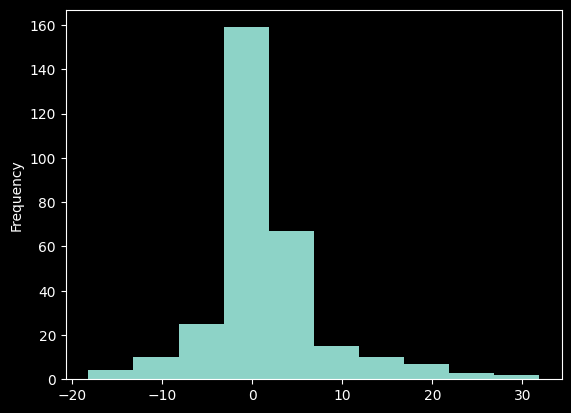

In [51]:
backtest_results["bps_error"].plot.hist()

In [52]:
print(backtest_results["bps_error"].mean(), backtest_results["bps_error"].std(),
      backtest_results["bps_error"].quantile(0.05), backtest_results["bps_error"].quantile(0.95))

1.5240196811009248 6.357433638182126 -7.082301123756567 14.599268977638463


<Axes: xlabel='time'>

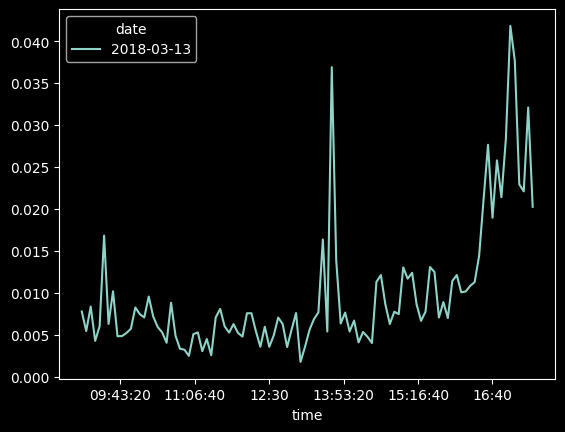

In [53]:
worst_day = backtest_results[backtest_results["bps_error"]==backtest_results["bps_error"].max()]
static_test_set[worst_day["date"]].plot()

### 🔄 **4.2 Algoritmo VWAP Dinámico**

#### 🎯 **Funcionalidad Avanzada:**

Ahora vamos a crear un **algoritmo VWAP dinámico** que use las predicciones dinámicas de volumen:

#### 🔄 **Proceso en Cada Bin:**

1. **📊 Estimación:** Usa el predictor dinámico para estimar el volumen total del día
2. **📈 Cálculo:** Calcula cuánto volumen espera para los bins restantes del día  
3. **⚖️ Distribución:** Distribuye las acciones restantes proporcionalmente a este volumen esperado

In [54]:
# Your code here
class dynamic_vwap_algorithm():
    def __init__(self, volume, side, num_neighbours = 10):
        self.volume = volume
        self.side = side
        self.vol_predictor = dynamicVolumePredictor(num_neighbours)
        self.volume_executed = 0
        self.market_volume_executed = 0
        self.intraday_data = pd.DataFrame()

    def beforeMarketOpen(self, historical_df):
        ## train model
        self.volume_executed = 0
        self.market_volume_executed = 0
        self.intraday_data = pd.DataFrame()
        historical_pivot = historical_df.reset_index()[["date", "time", "volume"]].pivot_table(index = "time", columns = "date", values = "volume", aggfunc = "first")
        self.vol_predictor.train(historical_pivot)

    def onDataEvent(self, intraday_df):
        current_time = intraday_df.iloc[0]["time"]
        current_volume = float(intraday_df["volume"].iloc[0]) if not pd.isna(intraday_df["volume"].iloc[0]) else 0
        
        # Update market volume executed
        self.market_volume_executed += current_volume
        
        # Build intraday data frame for prediction
        if self.intraday_data.empty:
            self.intraday_data = pd.DataFrame({current_time: [current_volume]}, index=[current_time])
        else:
            # Add new row to intraday data
            self.intraday_data.loc[current_time, current_time] = current_volume
        
        # Get prediction using the intraday data collected so far
        try:
            next_bin_volume, total_volume = self.vol_predictor.predict(self.intraday_data)
            next_volume = self.volume * (self.market_volume_executed + next_bin_volume) / total_volume - self.volume_executed
        except:
            # Fallback to simple proportional allocation if prediction fails
            next_volume = self.volume * 0.01  # Small fixed amount
        
        self.volume_executed += next_volume
        order_manager = OrderManager()
        order_manager.submitOrder(self.side, next_volume)
        return order_manager

#### ✅ **Validación del Algoritmo Dinámico:**

Prueba el algoritmo dinámico para el mismo día que probaste el algoritmo estático:

In [55]:
backtesting = BacktestingSession()
myalgo_dyn = dynamic_vwap_algorithm(1000, 1)
backtest_results_dyn = backtesting.run_backtest(data_resample_df, myalgo_dyn, split_date)

In [56]:
backtest_results_dyn["bps_error"] = 10000 * (backtest_results_dyn["vwap_algo"] -  backtest_results_dyn["vwap_market"]) / backtest_results_dyn["vwap_market"]

In [57]:
print(backtest_results_dyn["bps_error"].mean(), backtest_results_dyn["bps_error"].std())

1.5006918173072794 5.415865900451799


<Axes: ylabel='Frequency'>

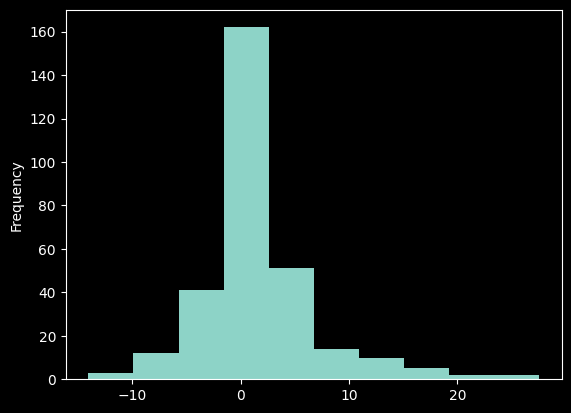

In [58]:
backtest_results_dyn["bps_error"].plot.hist()

<Axes: xlabel='time'>

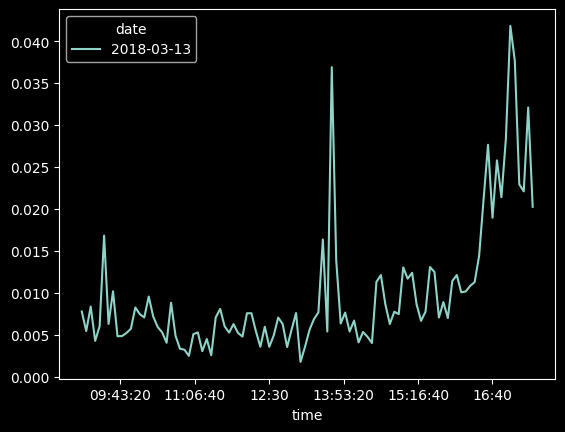

In [59]:
worst_day = backtest_results_dyn[backtest_results_dyn["bps_error"]==backtest_results_dyn["bps_error"].max()]
static_test_set[worst_day["date"]].plot()

<Axes: xlabel='time'>

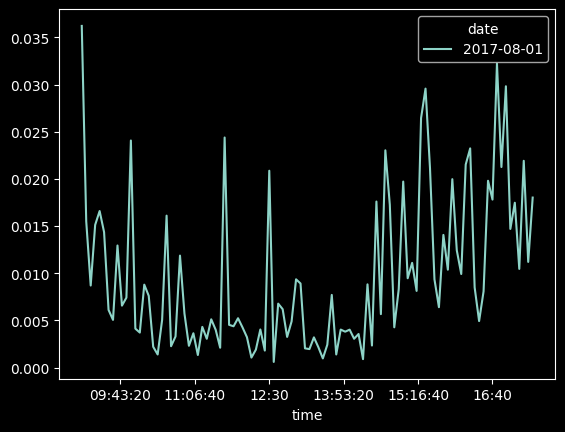

In [60]:
worst_day_left = backtest_results_dyn[backtest_results_dyn["bps_error"]==backtest_results_dyn["bps_error"].min()]
static_test_set[worst_day_left["date"]].plot()